In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so

nCells = {"LDC-S": 1030301, "LDC-M": 8120601, "Wind": 6517376}
cases = {"LDC-S": "Lid-Driven-Cavity S", "LDC-M": "Lid-Driven-Cavity M", "Wind": "WindsorBody"}

all = pd.read_csv("results/results_f64.csv", skip_blank_lines=True)
normd = []
for ms, case in zip(all["time_mean_ms"], all["case_short"]):
    normd.append(ms/nCells[case])
all["time_mean_ns_normed"] = normd
cpu_df = all[all["executor"]=="cpu"]
noLaplace = all[~all["variant"].str.contains("Only")]
gpu_df = all[all["executor"] == "gpu"]
filtered = cpu_df[~cpu_df["variant"].str.contains("Only")]
gpufiltered = gpu_df[~gpu_df["variant"].str.contains("Only")]
sorted_variants = sorted(cpu_df["variant"].unique())
sorted_variants_filtered = sorted(noLaplace["variant"].unique())
fused_df = all[all["use_fusing"]]
sb.set_theme()


In [8]:
fused_df

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,precision,executor,use_kernelAbstractions,use_fusing,time_mean_ns_normed
7,67.650433,67.433232,0.0,0.0,LDC-S,Lid-Driven Cavity S,faceBased,FusedDivLap,julia,float64,cpu,False,True,6.566084e-05
21,26.470300,26.433007,0.0,0.0,LDC-S,Lid-Driven Cavity S,globalFaceBased,FusedDivLap,julia,float64,cpu,False,True,2.569181e-05
35,59.548534,59.521502,0.0,0.0,LDC-S,Lid-Driven Cavity S,cellBased,FusedDivLap,julia,float64,cpu,False,True,5.779722e-05
49,226.116762,226.183183,0.0,0.0,Wind,WindsorBody,faceBased,FusedDivLap,julia,float64,cpu,False,True,3.469445e-05
63,175.238634,175.161237,0.0,0.0,Wind,WindsorBody,globalFaceBased,FusedDivLap,julia,float64,cpu,False,True,2.688791e-05
77,337.136395,337.086821,0.0,0.0,Wind,WindsorBody,cellBased,FusedDivLap,julia,float64,cpu,False,True,5.172885e-05
91,195.813460,195.664676,0.0,0.0,LDC-M,Lid-Driven Cavity M,faceBased,FusedDivLap,julia,float64,cpu,False,True,2.411317e-05
105,203.890531,203.903669,0.0,0.0,LDC-M,Lid-Driven Cavity M,globalFaceBased,FusedDivLap,julia,float64,cpu,False,True,2.510781e-05
119,405.165887,404.807147,0.0,0.0,LDC-M,Lid-Driven Cavity M,cellBased,FusedDivLap,julia,float64,cpu,False,True,4.989358e-05
130,6.934580,6.932992,0.0,0.0,Wind,WindsorBody,cellBased,FusedDivLap,julia,float64,gpu,True,True,1.064014e-06


In [ ]:
def float_to_power10(x):
    s = f"{x:.6e}"          # scientific notation string
    mantissa, exp = s.split('e')
    if round(float(mantissa), 1) == 1.0:
        return fr"$10^{int(exp)}$"
    else:
        return fr"${round(float(mantissa), 1)}\cdot 10^{int(exp)}$"
def add_yticks_suffix(ax, suffix, toExp=True, doRound=True):
    ticks = ax.get_yticks()
    suffixed = [""]*len(ticks)
    for i in range(len(ticks)):
        x = ticks[i]
        if toExp:
            x = float_to_power10(x)
        else:
            if doRound:
                x = str(int(x))
            else:
                x = str(round(x, 2))

        suffixed[i] = x + suffix

    ax.yaxis.set_ticklabels(suffixed)

SyntaxError: f-string: single '}' is not allowed (950195756.py, line 7)

In [33]:
def draw_boxplot(data, x, y, save=False, annotate=False, useLog=False, ylabel="", xlabel="",ax=None, rotate=False):
    yl = ylabel or y
    xl = xlabel or x
    if ax:
        plot = sb.boxplot(data=data, ax=ax, x=x, y=y, log_scale=useLog, gap=.1)
        plot.set(
            ylabel=yl, xlabel=xl
        )
    else:
        plot = sb.boxplot(data=data, x=x, y=y, log_scale=useLog, gap=.1)
        plot.set(
            ylabel=yl, xlabel=xl
        )
    if annotate:
        minvals = data.loc[data.groupby("strategy")["time_mean_ms"].idxmin()]
        mapping = {"faceBased": 0, "globalFaceBased": 1, "cellBased": 2}
        for i, row in minvals.iterrows():
            plot.annotate(row["variant"],
                    xy=(mapping[row["strategy"]], row[y]),
                    fontsize=12)
    if rotate:  
        plot.set_xticklabels(plot.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right'
        )

    if save:
        plt.savefig(f"figures/{save}.svg")

/tmp/ipykernel_15885/549852822.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/tmp/ipykernel_15885/549852822.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/tmp/ipykernel_15885/549852822.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),


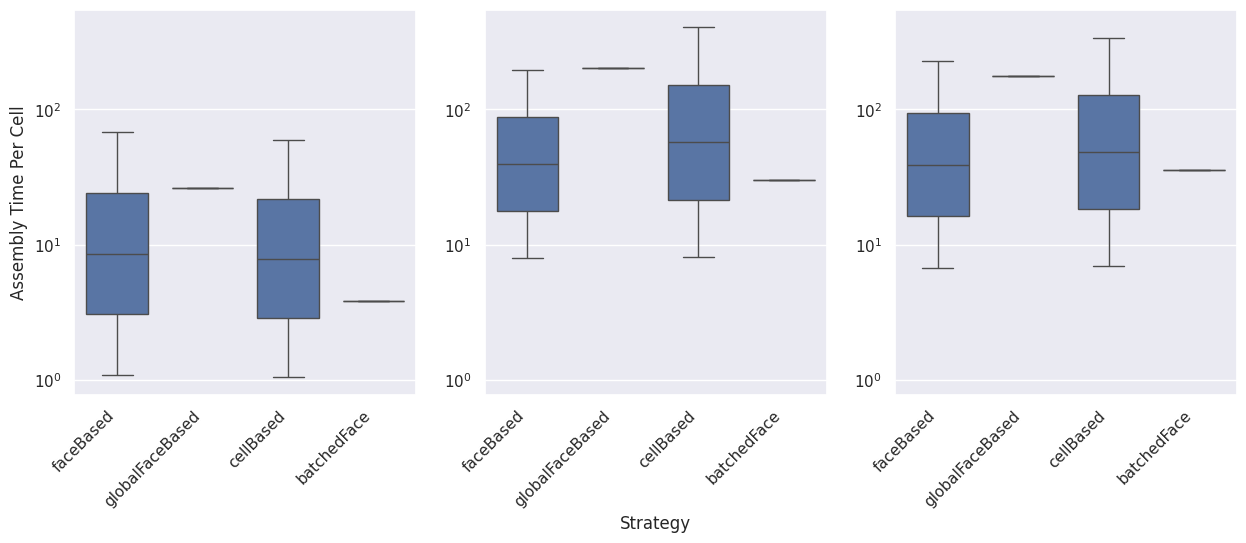

In [84]:
fig, axes = plt.subplots(1,3, figsize=(15, 5), sharey=True)
for i, ax in enumerate(axes.flat):
    case_df = fused_df[fused_df["case_short"] == list(cases.keys())[i]]
    plot = sb.boxplot(data=case_df, ax=ax, x="strategy", y="time_mean_ms", gap=.1, log_scale=True)
    plot.set_xticklabels(plot.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
    )
    plot.set(
        ylabel="Assembly Time Per Cell"
    )
    if i == 1:
        plot.set(xlabel="Strategy")
    else:
        plot.set(xlabel="")
    # draw_boxplot(case_df, ax=ax, x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel=list(cases.values())[i], useLog=False, ylabel="Mean Assembly Time", rotate=True)
    ax.yaxis.set_tick_params(labelleft=True)


time_mean_ms Mean Assembly Time (ms)
time_mean_ns_normed Mean Assembly Time Per Cell (ms)


/tmp/ipykernel_15885/1487346314.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),
/tmp/ipykernel_15885/1487346314.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


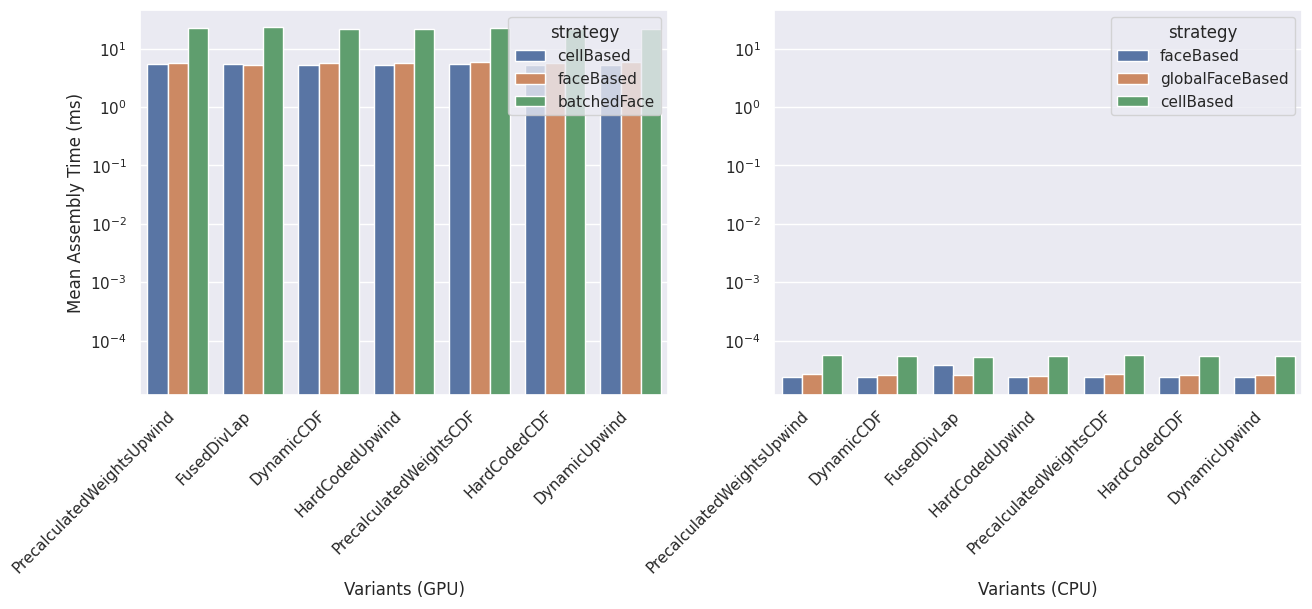

In [69]:
fig, axes = plt.subplots(1,2, figsize=(15, 5), sharey=True)

for i, ax in enumerate(axes.flat):
    y = "time_mean_ms" if i == 0 else "time_mean_ns_normed"
    yl = "Mean Assembly Time (ms)" if i == 0 else "Mean Assembly Time Per Cell (ms)"
    print(y,yl)
    if i == 1:
        p =  sb.barplot(filtered, ax=ax, x="variant", y=y, hue="strategy", errorbar=None)
        p.set(xlabel="Variants (CPU)")
    else :
        p =  sb.barplot(gpufiltered, ax=ax, x="variant", y=y, hue="strategy", errorbar=None)
        p.set(xlabel="Variants (GPU)")

    p.set_yscale("log")
    p.set(
        ylabel=yl,
    )

    p.set_xticklabels(p.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right'
    )
    ax.yaxis.set_tick_params(labelleft=True)


time_mean_ms Mean Assembly Time (ms)
time_mean_ns_normed Mean Assembly Time Per Cell (ms)


/tmp/ipykernel_15885/4080029964.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),
/tmp/ipykernel_15885/4080029964.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


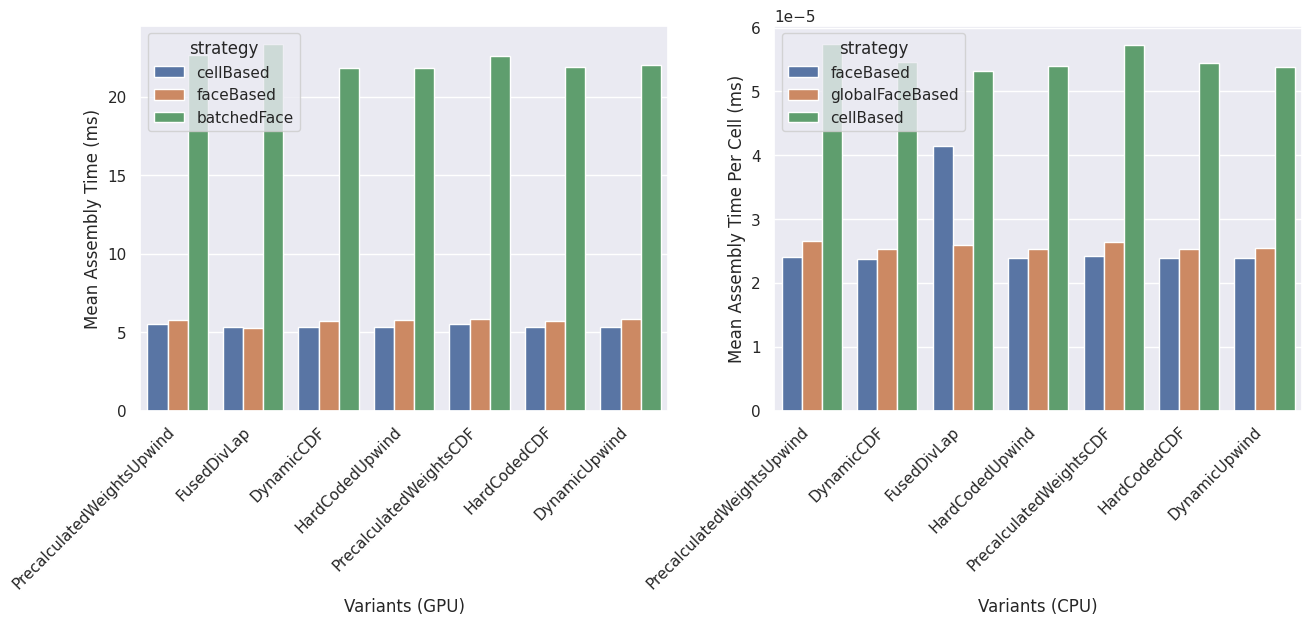

In [71]:
fig, axes = plt.subplots(1,2, figsize=(15, 5), sharey=False)

for i, ax in enumerate(axes.flat):
    y = "time_mean_ms" if i == 0 else "time_mean_ns_normed"
    yl = "Mean Assembly Time (ms)" if i == 0 else "Mean Assembly Time Per Cell (ms)"
    print(y,yl)
    if i == 1:
        p =  sb.barplot(filtered, ax=ax, x="variant", y=y, hue="strategy", errorbar=None)
        p.set(xlabel="Variants (CPU)")
    else :
        p =  sb.barplot(gpufiltered, ax=ax, x="variant", y=y, hue="strategy", errorbar=None)
        p.set(xlabel="Variants (GPU)")

    # p.set_yscale("log")
    p.set(
        ylabel=yl,
    )

    p.set_xticklabels(p.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right'
    )
    ax.yaxis.set_tick_params(labelleft=True)


/tmp/ipykernel_15885/2944692702.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/tmp/ipykernel_15885/2944692702.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/tmp/ipykernel_15885/2944692702.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),


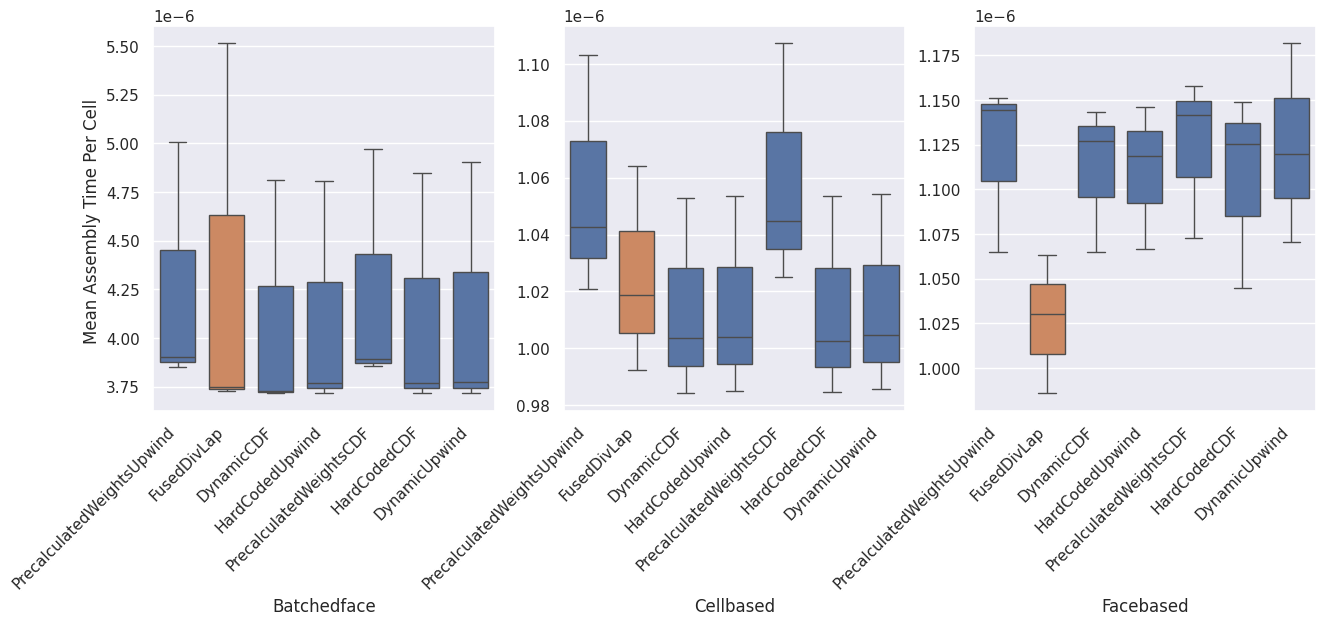

In [92]:
strategies = sorted(gpufiltered["strategy"].unique())

fig, axes = plt.subplots(1,len(strategies), figsize=(15, 5), sharey=False)
for i, ax in enumerate(axes.flat):
    case_df = gpufiltered[gpufiltered["strategy"] == strategies[i]]
    plot = sb.boxplot(data=case_df, ax=ax, x="variant", y="time_mean_ns_normed", gap=.1, log_scale=False, hue="use_fusing", legend=False)
    plot.set_xticklabels(plot.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
    )
    if i == 0:
        plot.set(
            ylabel="Mean Assembly Time Per Cell ",
        )
    else: 
        plot.set(
            ylabel="",
        )
    plot.set(xlabel=strategies[i].capitalize())
    ax.yaxis.set_tick_params(labelleft=True)



In [136]:
list(all[['strategy', 'executor']].drop_duplicates().sort_values(by=['executor', 'strategy']).itertuples())

[Pandas(Index=28, strategy='cellBased', executor='cpu'),
 Pandas(Index=0, strategy='faceBased', executor='cpu'),
 Pandas(Index=14, strategy='globalFaceBased', executor='cpu'),
 Pandas(Index=168, strategy='batchedFace', executor='gpu'),
 Pandas(Index=126, strategy='cellBased', executor='gpu'),
 Pandas(Index=154, strategy='faceBased', executor='gpu')]

/tmp/ipykernel_79441/300319513.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/tmp/ipykernel_79441/300319513.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/tmp/ipykernel_79441/300319513.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),


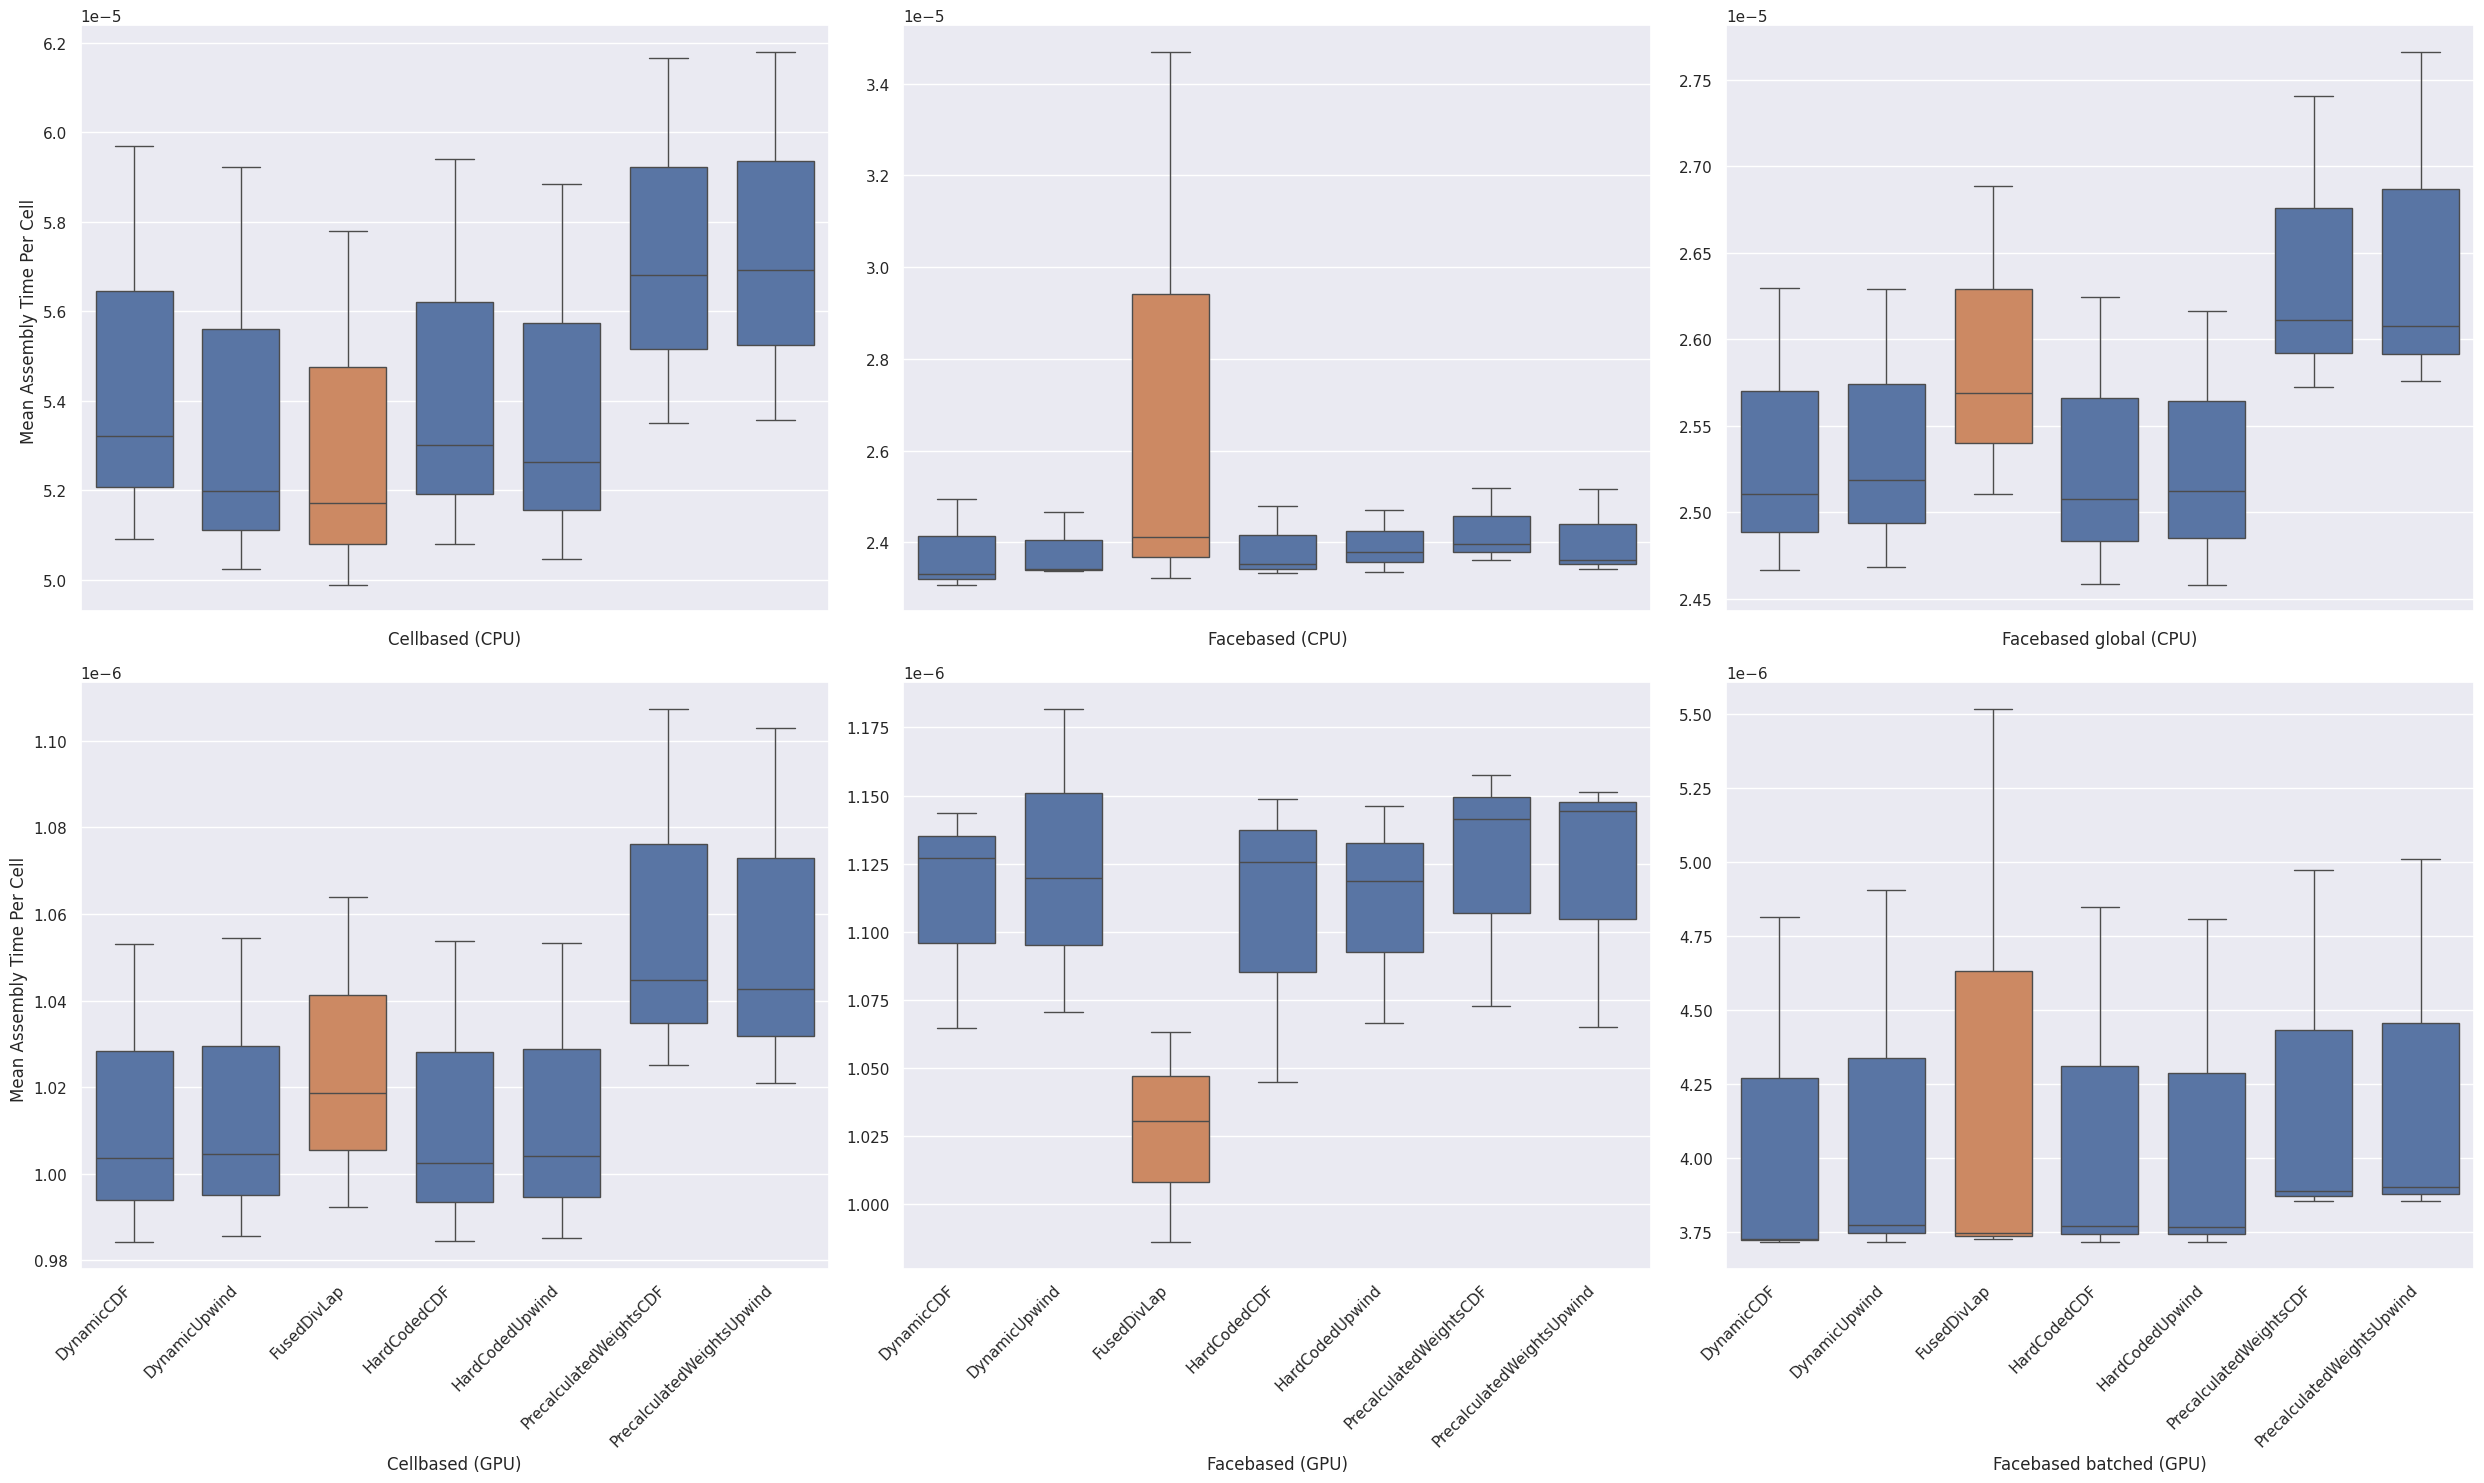

In [3]:
strategies = list(noLaplace[['strategy', 'executor']].drop_duplicates().sort_values(by=['executor', 'strategy']).itertuples())

fig, axes = plt.subplots(2,3, figsize=(25,15), sharey=False)
for i, ax in enumerate(axes.flat):
    strat = strategies[i]
    case_df = noLaplace[noLaplace["strategy"] == strat.strategy]
    case_df = case_df[case_df["executor"]==strat.executor]

    plot = sb.boxplot(data=case_df, ax=ax, x="variant", y="time_mean_ns_normed", gap=.1, log_scale=False, hue="use_fusing", legend=False, order=sorted_variants_filtered)
    if i > 2:
        plot.set_xticklabels(plot.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right'
        )
    else:
        plot.set_xticklabels([], 
                            rotation=45, 
                            horizontalalignment='right'
        )
    if i == 0 or i == 3:
        plot.set(
            ylabel="Mean Assembly Time Per Cell ",
        )
    else: 
        plot.set(
            ylabel="",
        )
    plot.set(xlabel=f"{strat.strategy.capitalize()} ({strat.executor.upper()})")
    ax.yaxis.set_tick_params(labelleft=True)
    plt.tight_layout()
    plt.savefig(f"figures/normed_all.svg")
